In [5]:
import numpy as np
import pandas as pd

# Leer archivo
df = pd.read_excel("Beta Ecopetrol.xlsx")

# Tomar las últimas dos columnas
ultimas_dos = df.iloc[:, -2:].copy()

# Convertir a numérico por si vienen como texto
for c in ultimas_dos.columns:
    ultimas_dos[c] = pd.to_numeric(ultimas_dos[c], errors="coerce")

# Eliminar filas con nulos
ultimas_dos = ultimas_dos.dropna()

# Identificar columna de Ecopetrol (heurística por nombre)
cols = list(ultimas_dos.columns)
eco_candidates = [
    c for c in cols if "eco" in str(c).lower() or "ecopetrol" in str(c).lower()
]

if eco_candidates:
    eco_col = eco_candidates[0]
    mkt_col = [c for c in cols if c != eco_col][0]
else:
    # Si no se puede identificar por nombre, asumir:
    # primera = Ecopetrol, segunda = mercado
    eco_col, mkt_col = cols[0], cols[1]

# Cálculo de beta: Cov(R_eco, R_mkt) / Var(R_mkt)
cov = np.cov(ultimas_dos[eco_col], ultimas_dos[mkt_col], ddof=1)[0, 1]
var_mkt = np.var(ultimas_dos[mkt_col], ddof=1)
beta_ecopetrol = cov / var_mkt

print("Columnas usadas:")
print(f"  Ecopetrol: {eco_col}")
print(f"  Mercado:   {mkt_col}")
print(f"Beta de Ecopetrol: {beta_ecopetrol:.6f}")

Columnas usadas:
  Ecopetrol: rECOP - rf
  Mercado:   rCOLCAP - rf
Beta de Ecopetrol: 1.215117


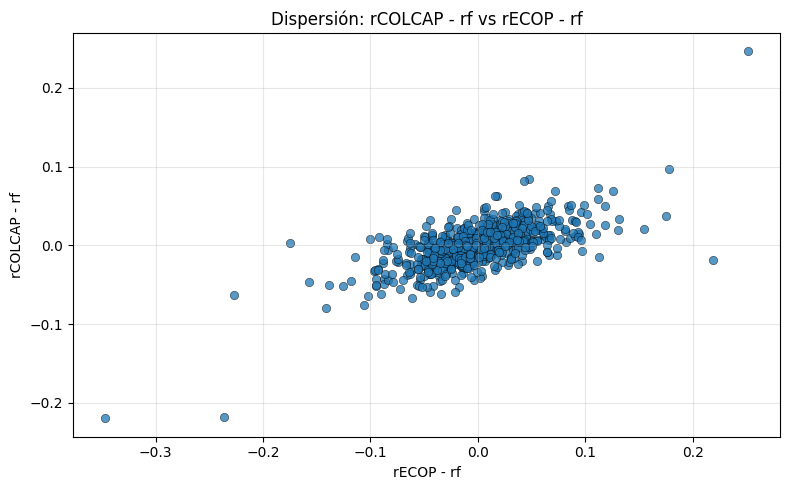

In [6]:
import matplotlib.pyplot as plt

# Gráfica de dispersión entre las dos últimas columnas
x_col, y_col = ultimas_dos.columns[0], ultimas_dos.columns[1]

plt.figure(figsize=(8, 5))
plt.scatter(
    ultimas_dos[x_col],
    ultimas_dos[y_col],
    alpha=0.75,
    edgecolors="black",
    linewidths=0.4,
)
plt.title(f"Dispersión: {y_col} vs {x_col}")
plt.xlabel(x_col)
plt.ylabel(y_col)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()